A common empirical relationship is that concrete compressive strength decreases as the water–cement ratio increases.

We simulate experimental lab data where:

- \( x \) = water–cement ratio  
- \( y \) = compressive strength (MPa)

We assume a linear trend:

strength = 15 - 8x + noise

In [41]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

## Simulated Laboratory Data (water-cement ratio vs strength)

In [55]:
np.random.seed(0)
N = 50

# Water-cement ratio
X = 0.2 + 0.4 * np.random.rand(N, 1)

# Concrete compressive strength (MPa)
# True relationship: strength decreases with higher water content (simplified linear model)
y = 15 - 8 * X[:, 0] + 0.5*np.random.randn(N)

## We aim to estimate the relationship between water-cement ratio (input) and concrete compressive strength (output) using ordinary least squares linear regression.

In [56]:
# Build the design matrix adding bias term (intercept column of ones)
X_design = np.hstack([np.ones((N, 1)), X])

## Linear regression model via ordinary least squares

In [57]:
# Closed-form least squares solution
beta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

print("Estimated parameters (intercept, slope):", beta)

Estimated parameters (intercept, slope): [15.07321172 -8.38408382]


## Prediction for new data

In [58]:
# Prediction strength curve
X_test = np.linspace(0.2, 0.6, 100).reshape(-1, 1)
X_test_design = np.hstack([np.ones((100, 1)), X_test])

y_pred = X_test_design @ beta

## Visualization 

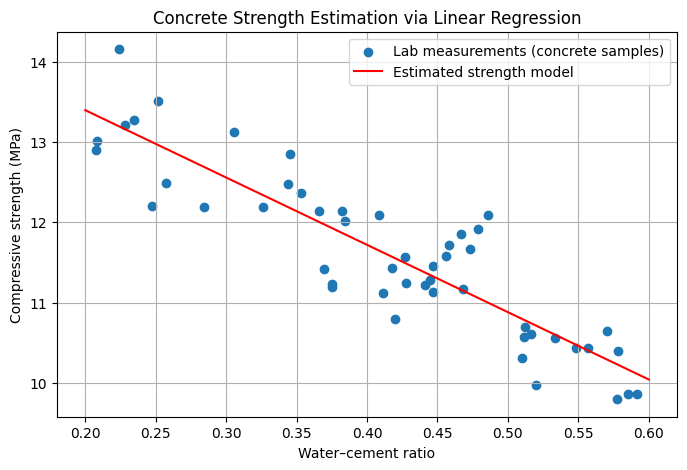

In [59]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Lab measurements (concrete samples)")
plt.plot(X_test, y_pred, label="Estimated strength model", color="red")

plt.xlabel("Water–cement ratio")
plt.ylabel("Compressive strength (MPa)")
plt.title("Concrete Strength Estimation via Linear Regression")
plt.legend()
plt.grid(True)
plt.show()